In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv('../data/raw/ai4i2020.csv')
print("Data loaded!", df.shape)

Data loaded! (10000, 14)


In [3]:
import subprocess
subprocess.run(['pip', 'install', 'shap', 'lightgbm'], capture_output=True)
print("Installing... done!")

Installing... done!


In [4]:
import shap
import lightgbm as lgb
print("SHAP version:", shap.__version__)
print("LightGBM version:", lgb.__version__)

SHAP version: 0.49.1
LightGBM version: 4.6.0


In [5]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

X = df[['Air temperature [K]', 'Process temperature [K]',
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y = df['Machine failure']

# Rename columns — special characters hatao
X.columns = ['Air_temp', 'Process_temp', 'Rotational_speed', 'Torque', 'Tool_wear']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = LGBMClassifier(n_estimators=100, random_state=42,
                        verbose=-1, n_jobs=1)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Model trained!
Train size: (8000, 5), Test size: (2000, 5)


In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated!")
print("Shape:", shap_values.shape)

SHAP values calculated!
Shape: (2000, 5)


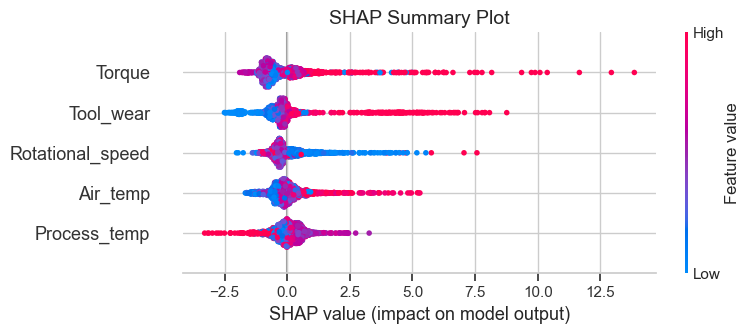

Saved!


In [7]:
# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/13_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

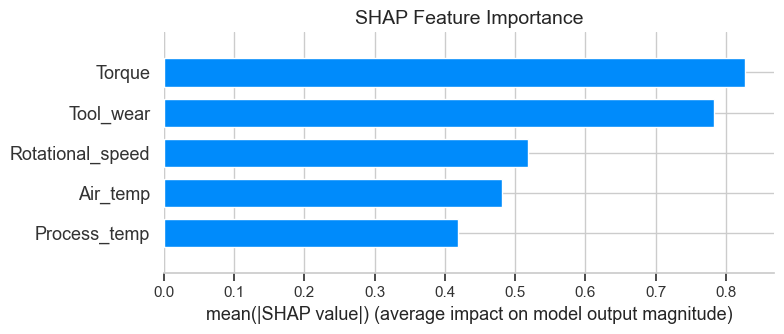

Saved!


In [8]:
# SHAP Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/14_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

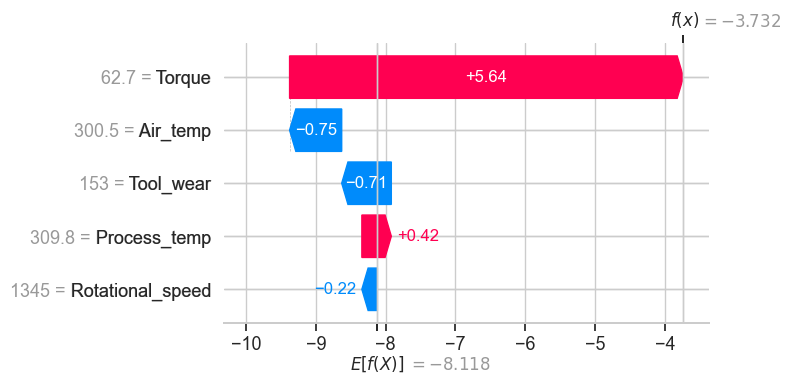

Saved!


In [9]:
# SHAP Waterfall Plot - single prediction explain karo
explainer2 = shap.TreeExplainer(model)
shap_explanation = explainer2(X_test)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation[0], show=False)
plt.tight_layout()
plt.savefig('../reports/figures/15_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

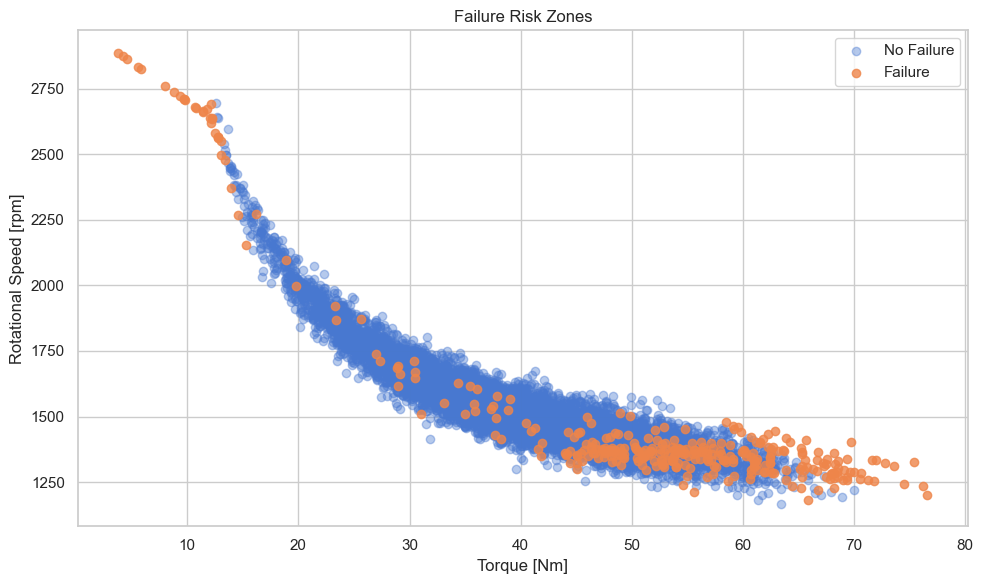

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

no_failure = df[df['Machine failure'] == 0]
failure = df[df['Machine failure'] == 1]

plt.scatter(
    no_failure['Torque [Nm]'],
    no_failure['Rotational speed [rpm]'],
    alpha=0.4,
    label='No Failure'
)

plt.scatter(
    failure['Torque [Nm]'],
    failure['Rotational speed [rpm]'],
    alpha=0.8,
    label='Failure'
)

plt.xlabel('Torque [Nm]')
plt.ylabel('Rotational Speed [rpm]')
plt.title('Failure Risk Zones')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    '../reports/figures/18_failure_risk_zones.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

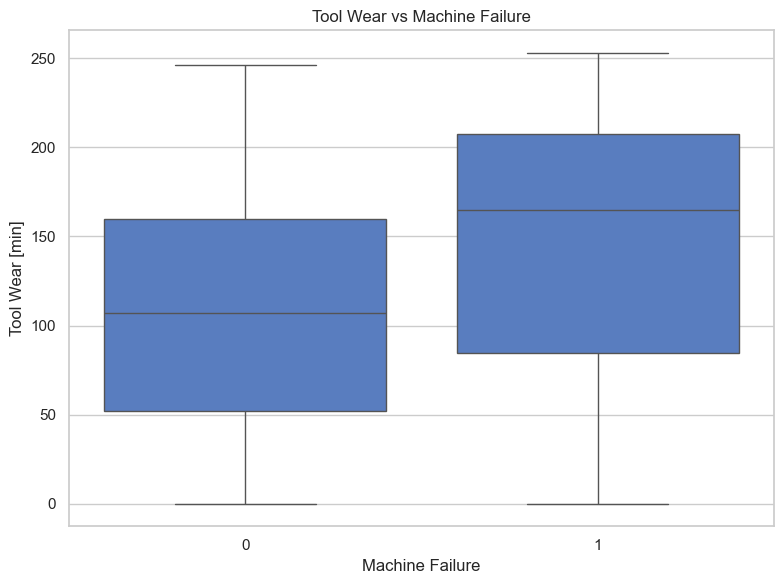

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Machine failure',
    y='Tool wear [min]'
)

plt.title('Tool Wear vs Machine Failure')
plt.xlabel('Machine Failure')
plt.ylabel('Tool Wear [min]')

plt.tight_layout()

plt.savefig(
    '../reports/figures/18_tool_wear_failure.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

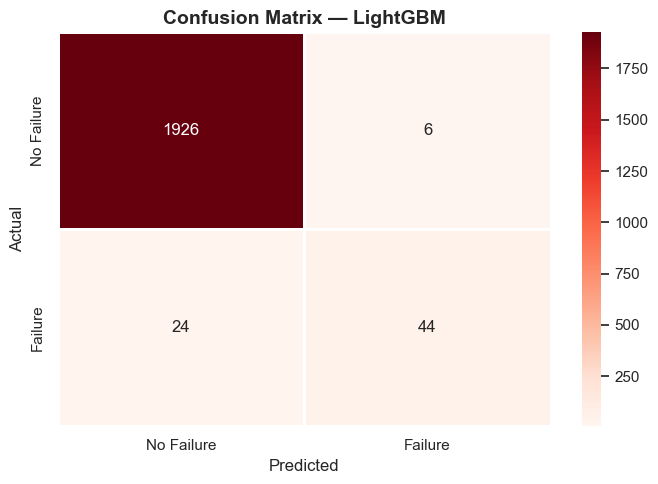

✅ Saved: 19_confusion_matrix.png


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'],
            linewidths=1, linecolor='white')
plt.title('Confusion Matrix — LightGBM', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/figures/19_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved: 19_confusion_matrix.png")

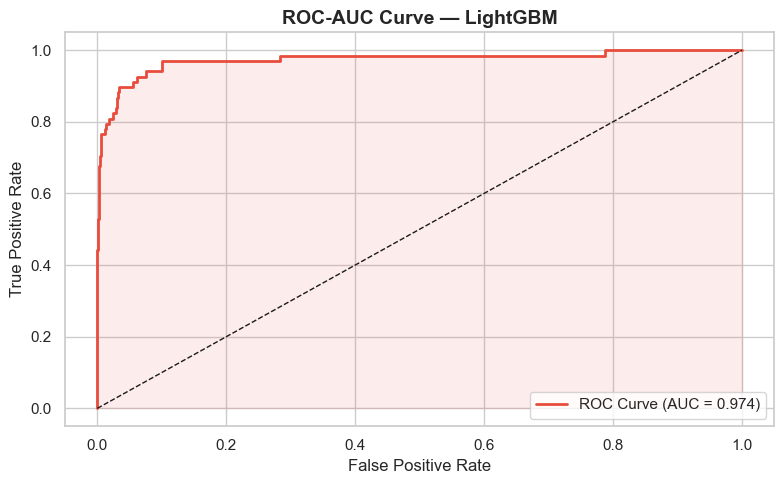

✅ Saved: 20_roc_auc_curve.png | AUC: 0.974


In [13]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve — LightGBM', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/20_roc_auc_curve.png', dpi=150)
plt.show()
print(f"✅ Saved: 20_roc_auc_curve.png | AUC: {roc_auc:.3f}")

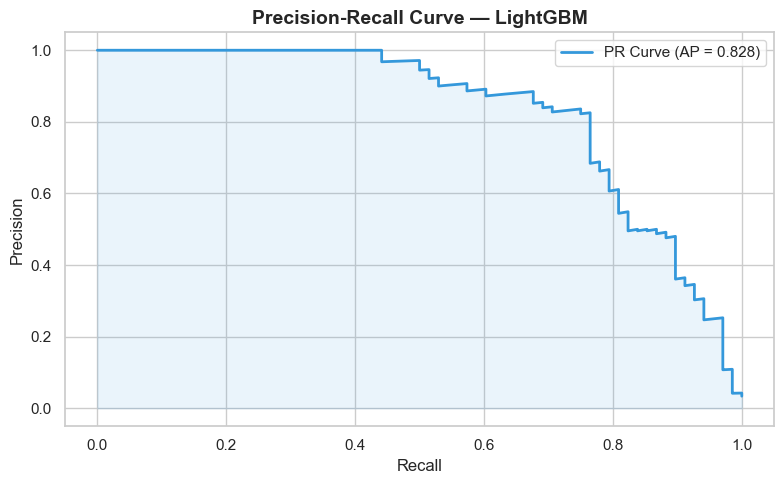

✅ Saved: 21_precision_recall.png | AP: 0.828


In [14]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='#3498db', lw=2,
         label=f'PR Curve (AP = {ap:.3f})')
plt.fill_between(recall, precision, alpha=0.1, color='#3498db')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — LightGBM', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/21_precision_recall.png', dpi=150)
plt.show()
print(f"✅ Saved: 21_precision_recall.png | AP: {ap:.3f}")

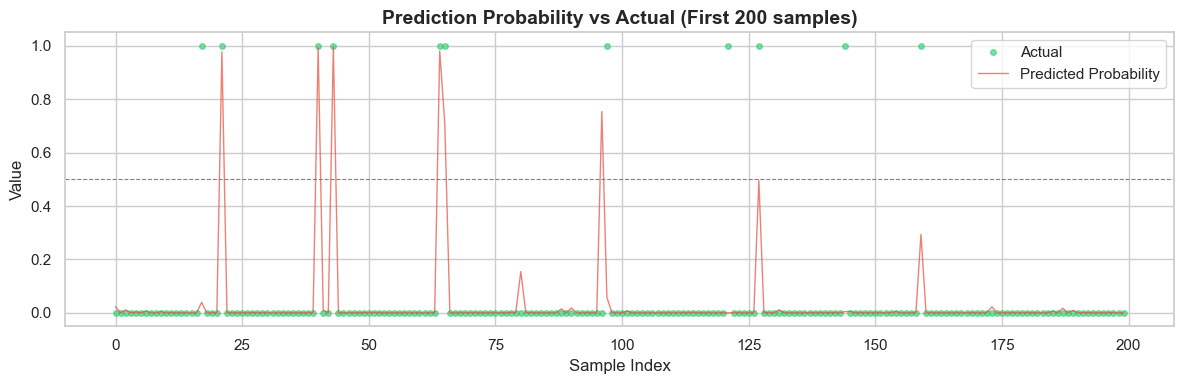

✅ Saved: 22_prediction_vs_actual.png


In [15]:
import numpy as np

results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Probability': y_pred_proba
}).reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.plot(results_df.index[:200],
         results_df['Actual'][:200],
         'o', color='#2ecc71', alpha=0.6, markersize=4, label='Actual')
plt.plot(results_df.index[:200],
         results_df['Probability'][:200],
         '-', color='#e74c3c', alpha=0.7, linewidth=1, label='Predicted Probability')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Prediction Probability vs Actual (First 200 samples)',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/22_prediction_vs_actual.png', dpi=150)
plt.show()
print("✅ Saved: 22_prediction_vs_actual.png")

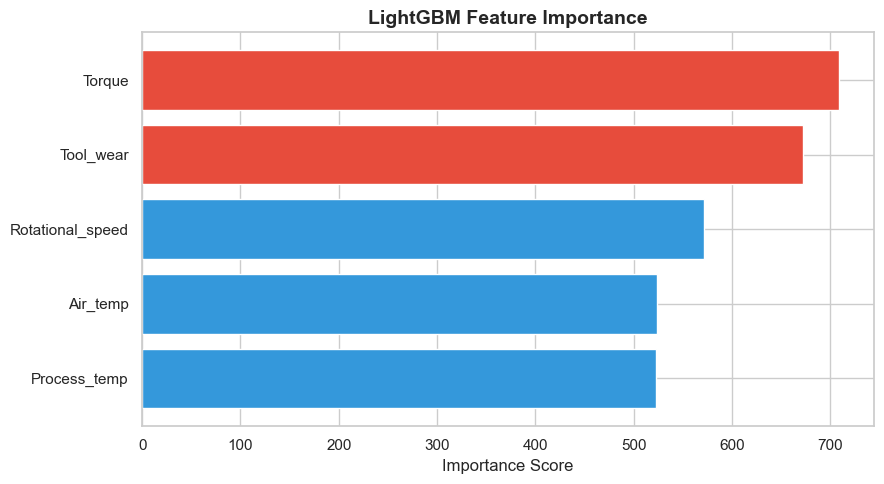

✅ Saved: 23_lgbm_feature_importance.png


In [16]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

colors = ['#e74c3c' if i >= len(importance_df)-2
          else '#3498db' for i in range(len(importance_df))]

plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color=colors, edgecolor='white')
plt.xlabel('Importance Score')
plt.title('LightGBM Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/23_lgbm_feature_importance.png', dpi=150)
plt.show()
print("✅ Saved: 23_lgbm_feature_importance.png")